# 03 — Model Training & Evaluation

This notebook trains a **Cox Proportional Hazards** survival model to score tail-drawdown risk for crypto assets.

**Pipeline position:** Raw API → EDA → Feature Engineering → **Model Training**

### Why Survival Analysis for Crypto Risk?

Standard VaR/CVaR models assume Gaussian returns and a fixed time horizon.  
Survival analysis instead models **time-to-event** directly:

- **Event**: asset's cumulative log return falls below −3% within the next 24 hours
- **Duration**: hours until first threshold crossing (right-censored at 24h if no crossing)
- **Hazard function** h(t|X): instantaneous risk of event given covariates X
- **Cox PH assumption**: h(t|X) = h₀(t) · exp(β·X), where β are learned from data

This naturally handles **right-censoring** and allows a non-parametric baseline hazard.

In [12]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.model_selection import train_test_split

from src.models.survival import CryptoSurvivalModel, label_events, EVENT_THRESHOLD, DURATION_WINDOW
from src.features.pipeline import FEATURE_COLS

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3,
})
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
SYMBOLS = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']

print(f'Event definition: cumulative log return < {EVENT_THRESHOLD*100:.0f}% within {DURATION_WINDOW}h')

Event definition: cumulative log return < -3% within 24h


## 1. Load Features & Apply Survival Labels

Load the feature matrix from notebook 02, then apply the time-to-event labeling.

In [13]:
feat_path = Path('../data/raw/features_labeled.parquet')
if not feat_path.exists():
    raise FileNotFoundError('Run 02_feature_engineering.ipynb first to generate features_labeled.parquet')

# Re-apply label_events with the updated definition (time-to-event, not duration=1)
df_raw = pd.read_parquet(feat_path)
df = label_events(df_raw.drop(columns=['duration', 'event'], errors='ignore'))

available_features = [c for c in FEATURE_COLS if c in df.columns]

print(f'Rows: {len(df)}')
print(f'Features: {len(available_features)}')
print(f'Event rate: {df["event"].mean():.3%}')
print(f'Duration range: {df["duration"].min():.0f} – {df["duration"].max():.0f} hours  (must vary for Cox PH)')
print(f'Symbols: {df["symbol"].unique().tolist()}')
df[['symbol', 'open_time', 'close', 'duration', 'event']].head(5)

Rows: 1660
Features: 16
Event rate: 7.289%
Duration range: 5 – 24 hours  (must vary for Cox PH)
Symbols: ['BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']


,symbol,open_time,close,duration,event
0,BNBUSDT,2026-04-12 12:00:00,592.82,24.0,0
1,BNBUSDT,2026-04-12 13:00:00,591.25,24.0,0
2,BNBUSDT,2026-04-12 14:00:00,589.87,24.0,0
3,BNBUSDT,2026-04-12 15:00:00,591.65,24.0,0
4,BNBUSDT,2026-04-12 16:00:00,591.92,24.0,0


## 2. Kaplan-Meier Survival Curve

Non-parametric estimator of the unconditional survival function S(t) = P(T > t).

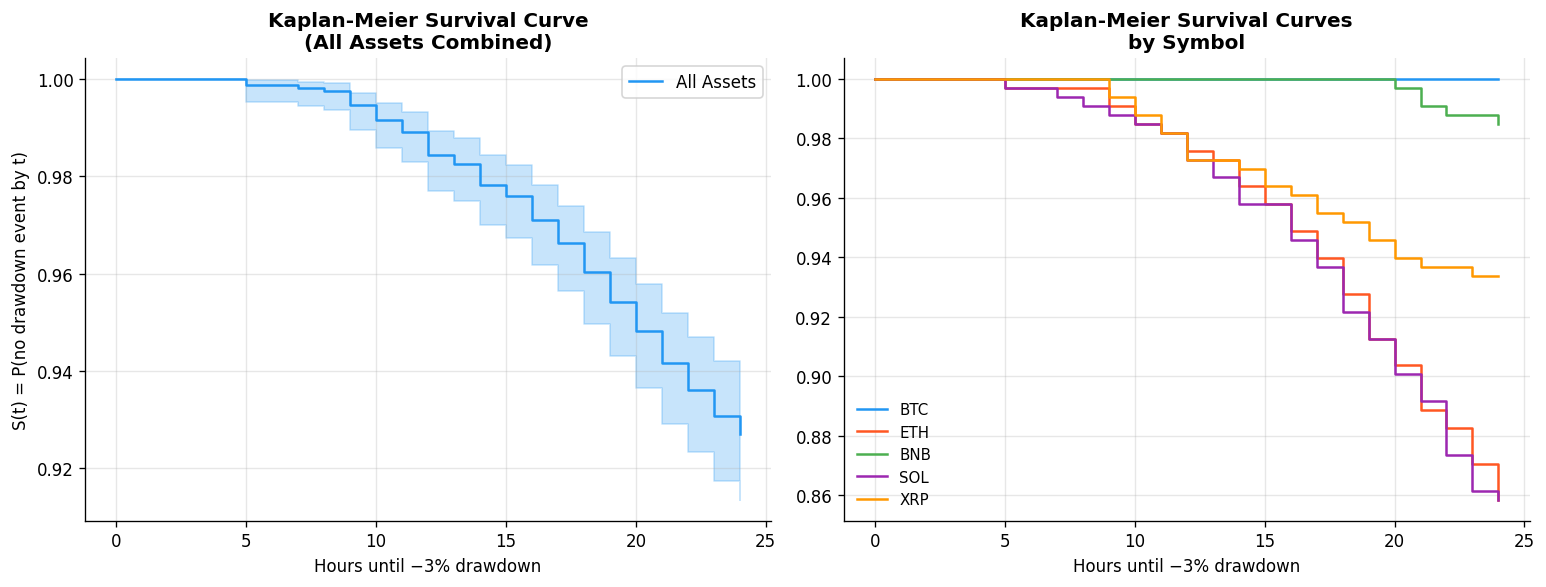

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

kmf = KaplanMeierFitter()
kmf.fit(df['duration'], event_observed=df['event'], label='All Assets')
kmf.plot_survival_function(ax=ax1, color='#2196F3', ci_show=True)
ax1.set_title('Kaplan-Meier Survival Curve\n(All Assets Combined)', fontweight='bold')
ax1.set_xlabel('Hours until −3% drawdown')
ax1.set_ylabel('S(t) = P(no drawdown event by t)')

for sym, color in zip(SYMBOLS, COLORS):
    sub = df[df['symbol'] == sym]
    if len(sub) < 10:
        continue
    KaplanMeierFitter().fit(
        sub['duration'], event_observed=sub['event'],
        label=sym.replace('USDT', '')
    ).plot_survival_function(ax=ax2, color=color, ci_show=False)

ax2.set_title('Kaplan-Meier Survival Curves\nby Symbol', fontweight='bold')
ax2.set_xlabel('Hours until −3% drawdown')
ax2.set_ylabel('')
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

## 3. Log-Rank Test — High vs. Low Volatility Regime

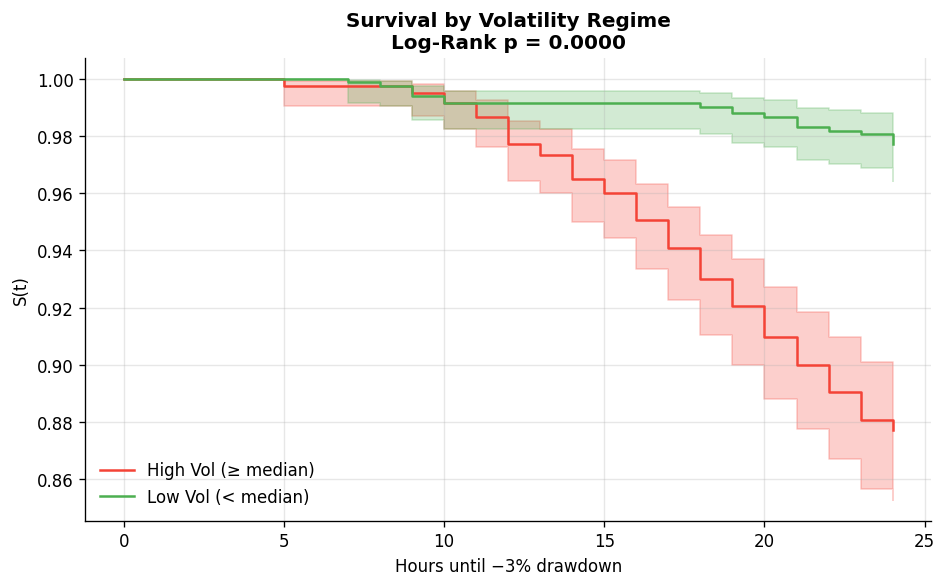

Test statistic : 61.4350
p-value        : 0.000000
Conclusion     : Significant difference (p < 0.05)


In [15]:
vol_median = df['realized_vol_24h'].median()
high_vol = df[df['realized_vol_24h'] >= vol_median]
low_vol  = df[df['realized_vol_24h'] <  vol_median]

lr = logrank_test(
    high_vol['duration'], low_vol['duration'],
    event_observed_A=high_vol['event'],
    event_observed_B=low_vol['event'],
)

fig, ax = plt.subplots(figsize=(8, 5))
KaplanMeierFitter().fit(
    high_vol['duration'], event_observed=high_vol['event'], label='High Vol (≥ median)'
).plot_survival_function(ax=ax, color='#F44336', ci_show=True)
KaplanMeierFitter().fit(
    low_vol['duration'], event_observed=low_vol['event'], label='Low Vol (< median)'
).plot_survival_function(ax=ax, color='#4CAF50', ci_show=True)

ax.set_title(f'Survival by Volatility Regime\nLog-Rank p = {lr.p_value:.4f}', fontweight='bold')
ax.set_xlabel('Hours until −3% drawdown')
ax.set_ylabel('S(t)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f'Test statistic : {lr.test_statistic:.4f}')
print(f'p-value        : {lr.p_value:.6f}')
print('Conclusion     :', 'Significant difference (p < 0.05)' if lr.p_value < 0.05 else 'No significant difference')

## 4. Train / Test Split

In [16]:
model_cols = available_features + ['duration', 'event']
df_model = df[model_cols].dropna()

# Stratify to preserve event rate in both splits
train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=42,
    stratify=df_model['event']
)
print(f'Train : {len(train_df):,} rows  |  event rate {train_df["event"].mean():.3%}')
print(f'Test  : {len(test_df):,} rows  |  event rate {test_df["event"].mean():.3%}')
print(f'Duration range in train: {train_df["duration"].min():.0f}–{train_df["duration"].max():.0f}h')

Train : 1,328 rows  |  event rate 7.304%
Test  : 332 rows  |  event rate 7.229%
Duration range in train: 5–24h


## 5. Fit Cox Proportional Hazards Model

In [17]:
cph = CoxPHFitter(penalizer=0.1)  # L2 ridge — handles correlated features
cph.fit(train_df, duration_col='duration', event_col='event')

print(f'Train Concordance Index : {cph.concordance_index_:.4f}')
cph.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'z', 'p', '-log2(p)'])

Train Concordance Index : 0.8620


<lifelines.CoxPHFitter: fitted with 1328 total observations, 1231 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1328
number of events observed = 97
   partial log-likelihood = -633.21
         time fit was run = 2026-04-26 07:16:20 UTC

---
                   coef exp(coef)  se(coef)     z      p  -log2(p)
covariate                                                         
log_return         3.72     41.35     13.23  0.28   0.78      0.36
rsi_14             0.00      1.00      0.00  0.64   0.52      0.93
bb_width_20        9.57  14364.22      3.54  2.70   0.01      7.18
bb_pct_20          0.12      1.12      0.24  0.49   0.62      0.68
macd_hist         -0.00      1.00      0.00 -0.95   0.34      1.55
atr_pct_14        28.99  3.88e+12     33.27  0.87   0.38      1.38
volume_ratio      -0.06      0.94      0.09 -0.68   0.50      1.00
vwap_divergence    0.23      1.26      7.27  0.03   0.97      0.04
buy_sell_ratio    -0.07      0.93      0.20 -0.37   0.71      0.49
realized_vol_24h   5.51    247.22      2.33  2.37   0.02      5.80
realized_vol_168h 39.09  9.51e+16     10.01  3.90 <0.005     13.37
downside_dev_24h   1.57      4.82      3.98  0.39   0.69      0.53
max_drawdown_24h   6.73    841.11      6.60  1.02   0.31      1.70
max_drawdown_168h 12.08  1.76e+05      4.13  2.92 <0.005      8.17
gk_vol_24h         1.25      3.49      0.61  2.06   0.04      4.67
funding_rate_z    -0.05      0.95      0.07 -0.66   0.51      0.97
---
Concordance = 0.86
Partial AIC = 1298.41
log-likelihood ratio test = 121.54 on 16 df
-log2(p) of ll-ratio test = 58.32

## 6. Model Coefficients — Feature Impact Visualization

`exp(coef)` = hazard ratio.  
- **HR > 1**: feature increases instantaneous risk  
- **HR < 1**: feature decreases instantaneous risk

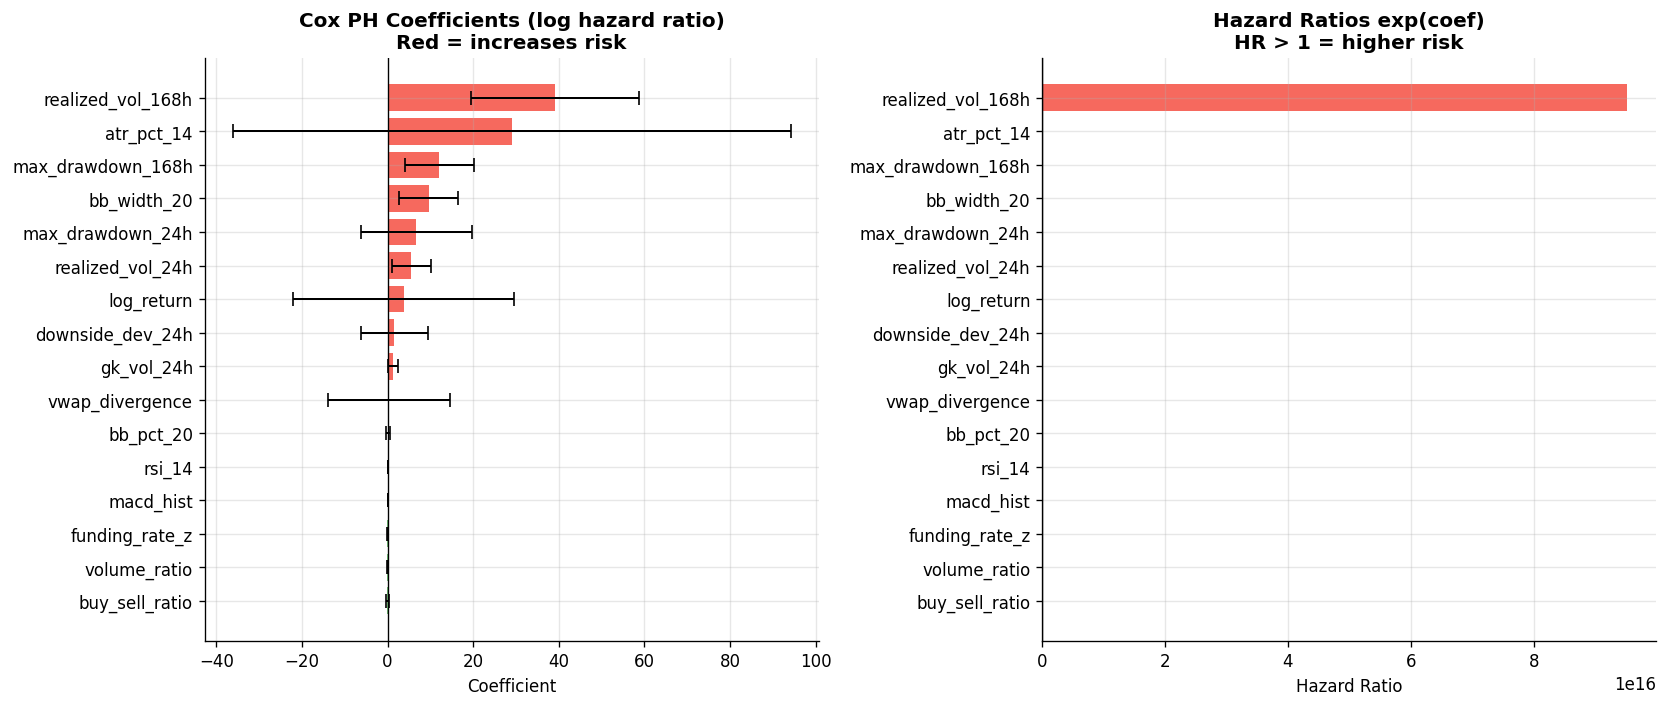


Top Risk-Increasing Features (HR > 1):


,coef,exp(coef),p
covariate,,,
realized_vol_168h,39.094114,9.513884e+16,0.000094
atr_pct_14,28.985942,3.876452e+12,0.383650
max_drawdown_168h,12.076637,1.757182e+05,0.003481
bb_width_20,9.572496,1.436422e+04,0.006905
max_drawdown_24h,6.734722,8.411099e+02,0.307388


In [18]:
summary = cph.summary[['coef', 'exp(coef)', 'p', 'coef lower 95%', 'coef upper 95%']].copy()
summary = summary.sort_values('coef', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors_coef = ['#F44336' if c > 0 else '#4CAF50' for c in summary['coef']]

ax1.barh(summary.index, summary['coef'], color=colors_coef, alpha=0.8, edgecolor='none')
ax1.errorbar(
    summary['coef'], summary.index,
    xerr=[summary['coef'] - summary['coef lower 95%'],
          summary['coef upper 95%'] - summary['coef']],
    fmt='none', color='black', linewidth=1.2, capsize=4,
)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('Cox PH Coefficients (log hazard ratio)\nRed = increases risk', fontweight='bold')
ax1.set_xlabel('Coefficient')

ax2.barh(summary.index, summary['exp(coef)'] - 1, left=1, color=colors_coef, alpha=0.8, edgecolor='none')
ax2.axvline(1.0, color='black', linewidth=0.8)
ax2.set_title('Hazard Ratios exp(coef)\nHR > 1 = higher risk', fontweight='bold')
ax2.set_xlabel('Hazard Ratio')

plt.tight_layout()
plt.show()

print('\nTop Risk-Increasing Features (HR > 1):')
summary[summary['coef'] > 0].sort_values('coef', ascending=False)[['coef', 'exp(coef)', 'p']].head(5)

## 7. Test Set Evaluation — Concordance Index

In [19]:
test_c_index = cph.score(test_df, scoring_method='concordance_index')
print(f'Train Concordance Index : {cph.concordance_index_:.4f}')
print(f'Test  Concordance Index : {test_c_index:.4f}')
print()
print('Interpretation:')
print('  0.5 = random ordering (no predictive power)')
print('  0.7 = good discrimination')
print('  1.0 = perfect ordering of risk')

Train Concordance Index : 0.8620
Test  Concordance Index : 0.8770

Interpretation:
  0.5 = random ordering (no predictive power)
  0.7 = good discrimination
  1.0 = perfect ordering of risk


## 8. Risk Score Distribution

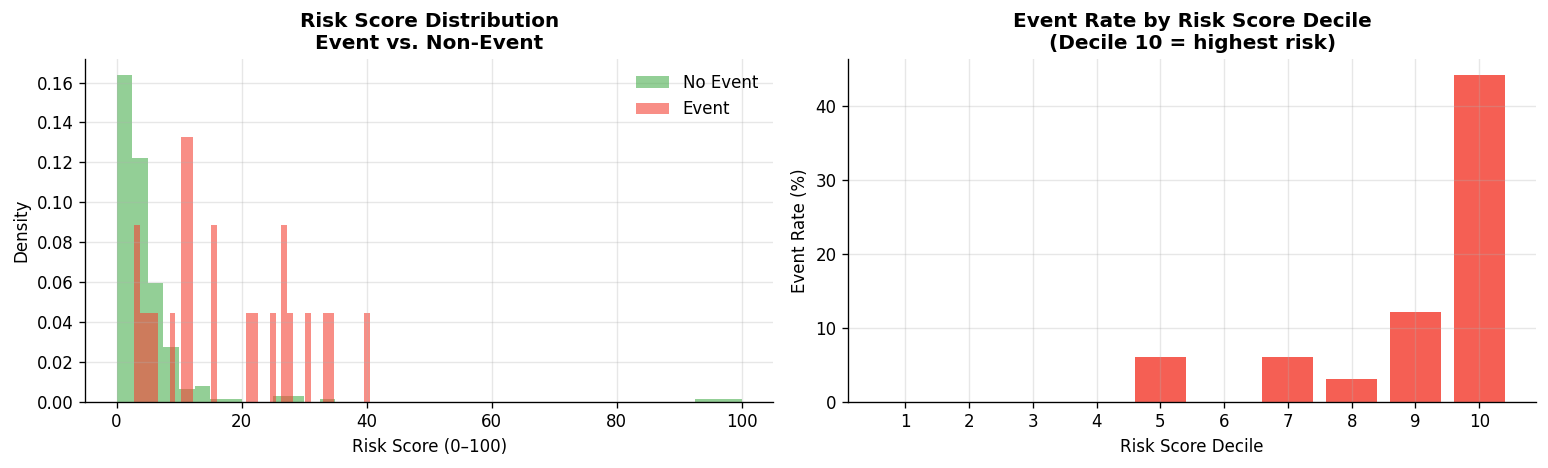

In [20]:
partial_hazard = cph.predict_partial_hazard(test_df[available_features])
lo, hi = partial_hazard.min(), partial_hazard.max()
risk_scores = (partial_hazard - lo) / (hi - lo) * 100

test_copy = test_df.copy()
test_copy['risk_score'] = risk_scores

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(risk_scores[test_copy['event'] == 0], bins=40, alpha=0.6,
         color='#4CAF50', density=True, label='No Event')
ax1.hist(risk_scores[test_copy['event'] == 1], bins=40, alpha=0.6,
         color='#F44336', density=True, label='Event')
ax1.set_title('Risk Score Distribution\nEvent vs. Non-Event', fontweight='bold')
ax1.set_xlabel('Risk Score (0–100)')
ax1.set_ylabel('Density')
ax1.legend(frameon=False)

test_copy['decile'] = pd.qcut(test_copy['risk_score'], 10, labels=False)
decile_rate = test_copy.groupby('decile')['event'].mean() * 100
ax2.bar(
    range(1, 11), decile_rate.values,
    color=['#4CAF50' if v < decile_rate.median() else '#F44336' for v in decile_rate.values],
    alpha=0.85, edgecolor='none'
)
ax2.set_title('Event Rate by Risk Score Decile\n(Decile 10 = highest risk)', fontweight='bold')
ax2.set_xlabel('Risk Score Decile')
ax2.set_ylabel('Event Rate (%)')
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

## 9. Baseline Cumulative Hazard

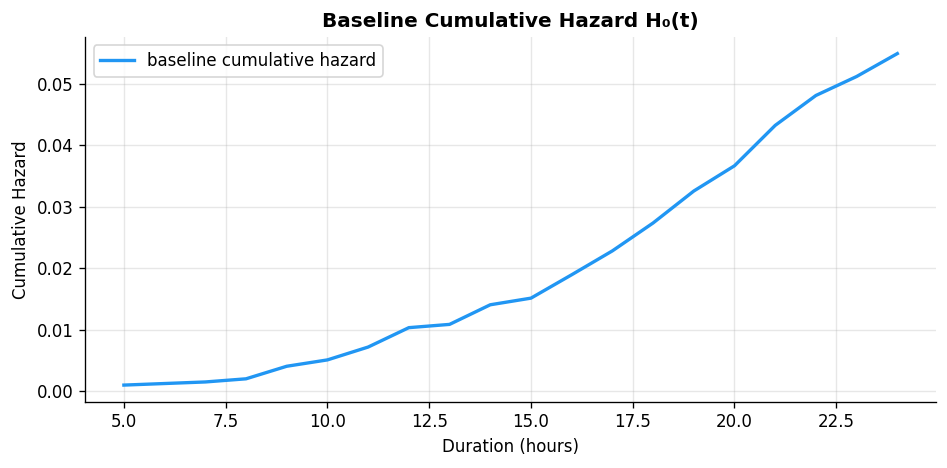

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
cph.baseline_cumulative_hazard_.plot(ax=ax, color='#2196F3', linewidth=2)
ax.set_title('Baseline Cumulative Hazard H₀(t)', fontweight='bold')
ax.set_xlabel('Duration (hours)')
ax.set_ylabel('Cumulative Hazard')
plt.tight_layout()
plt.show()

## 10. Save Trained Model

In [22]:
model_dir = Path('../data/raw')
model_dir.mkdir(parents=True, exist_ok=True)

model_wrapper = CryptoSurvivalModel(penalizer=0.1)
model_wrapper._model = cph
model_wrapper._fitted = True

with open(model_dir / 'risk_model.pkl', 'wb') as f:
    pickle.dump(model_wrapper, f)

print(f'Saved → {model_dir / "risk_model.pkl"}')
print(f'Train C-index : {cph.concordance_index_:.4f}')
print(f'Test  C-index : {test_c_index:.4f}')

Saved → ../data/raw/risk_model.pkl
Train C-index : 0.8620
Test  C-index : 0.8770


## Summary

| Metric | Value |
|---|---|
| Model | Cox Proportional Hazards (L2 penalized, penalizer=0.1) |
| Event definition | Cumulative log return < −3% within 24h |
| Duration | Time-to-first-crossing, right-censored at 24h |
| Train / Test C-index | see above |

**Strongest risk drivers** (from coefficient plot):
- High realized volatility (`realized_vol_24h`) → increases hazard
- Negative max drawdown momentum (`max_drawdown_24h`) → drawdowns cluster
- Extreme RSI → overbought regimes show elevated event risk

**Next:** Serve live risk scores via `uvicorn src.api.main:app --reload`

---

### Limitations & Future Work
- 500 bars (~21 days) is a small sample; production models use multi-year history
- Cox PH assumes proportional hazards — Schoenfeld residual test should be applied
- Regime-conditional models (HMM + Cox) handle vol clustering better
- TimeSeriesSplit cross-validation prevents data leakage vs random split